# Example 7: Prommer and Post 2013 (PHT3D Example 9) Kinetic degradation of BTEX using multiple electron acceptors
Biodegradation of a dissolved-phase, BTEX-type hydrocarbon plume is simulated through the sequential consumption of electron acceptors using Monod-type kinetics (Clement, 1997). The rate(s) of hydrocarbon removal include(s) inhibition terms representing the sequence of electron acceptor consumption from the most to least thermodynamically favorable degradation process. Changes to hydrocarbon concentrations are linked to electron acceptor availability by the stoichiometry of balanced mineralisation reactions, using toluene as a representative compound for the BTEX mixture. The contaminant source is simulated using an injection well in a homogeneous confined aquifer.

## Python Imports

In [1]:
from pathlib import Path
import shutil
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import flopy
from mf6rtm import utils, mup3d
import difflib
import re


In [2]:
# Phreeqc input file folders
prefix = 'ex7'
dataws = Path.cwd() / 'data'
databasews = Path.cwd() / 'database'
mf6_ws = Path.cwd() / prefix / 'mf6rtm'
pht3d_ws = Path.cwd() / prefix /'ex09_pht3d'

## Flow and Transport Setup

In [3]:
# Time discretization
time_units = 'days'
nper = 25  # Number of periods
nstp = 2 # number of time steps
perlen = 20 # simulation time (days)
perioddata = [[perlen, nstp, 1.] for kper in range(nper)]

# Spatial discretization
length_units = 'meters'
nlay = 1  # Number of layers
Lx = 510 # m
Ly = 310 # m
delr = 10 # Column width ($m$)
delc = 10 # Row width ($m$)
ncol = int(Lx/delc) # Number of columns
nrow =  int(Ly/delr) # Number of rows
top = 10.  # Top of the model ($m$)
botm = 0.  # Layer bottom elevations ($m$)
idomain = np.ones((nlay, nrow, ncol), dtype=int)
    
# Hydraulic properties
por = 0.3  # Porosity
k11 = 50.0  # Horizontal hydraulic conductivity ($m/d$)
k33 = k11  # Vertical hydraulic conductivity ($m/d$)

# Constant-head BCs
chd_in = [[(0,i,0),100] for i in range(nrow)]
chd_out = [[(0,i,ncol-1),99] for i in range(nrow)]
chd_spd = chd_in + chd_out

# Initial heads
strt = np.ones((nlay, nrow, ncol)) * 100.

# Injection Well (contaminant source)
q = 2 # m/d 
#wel_spd = {0:[(0,15,15),q]}
wel_spd = {0:[0,15,15,q]}

# Confined aquifer
icelltype = iconvert = 0

# Transport
alh = 10 # m
ath1 = 3 # m


# Initialize Chemistry in Domain

In [4]:
solutionsdf = pd.read_excel(dataws/ f"{prefix}_solutions.xlsx", comment='#', index_col=0)
solutions = utils.solution_df_to_dict(solutionsdf)
solutions

# assign solutions to grid (is this a multiplier on solutions dict or m0 in kinetics?)
sol_ic = np.ones((nlay, nrow, ncol), dtype=float)

# add solutions to class
solution = mup3d.Solutions(solutions)
solution.set_ic(sol_ic)

# kinetics
# num required, set as key of dict, why?
kinetics = utils.kinetics_phases_csv_to_dict(dataws / f"{prefix}_kinetic_phases.csv")
aerobic = 'O2 -1.0  Hy_carb  -0.11111111'
kinetics[1]['O(0)'].append(aerobic)
denitrif = 'NO3- -1.0  Hy_carb  -0.13888889'
kinetics[1]['N(5)'].append(denitrif)
iron_red = 'Fe+2     1.0  Hy_carb  -0.027777778'
kinetics[1]['Fe(2)'].append(iron_red)
sulfate_red = 'S(6)     1.0  Hy_carb  -0.22222222'
kinetics[1]['S(6)'].append(sulfate_red)
methanogen = 'Meth     1.0  Hy_carb  -0.22222222'
kinetics[1]['Meth'].append(methanogen)
kinetics
kinetics = mup3d.KineticPhases(kinetics)
kinetics.set_ic(1) # why 1?

# instantiate model class
model = mup3d.Mup3d(prefix, solution, nlay, nrow, ncol)

# set model workspace
if os.path.exists(mf6_ws):
    shutil.rmtree(mf6_ws)
model.set_wd(mf6_ws)

# set database
database = databasews / 'ex7_pht3d_datab.dat'
model.set_database(database)

model.set_phases(kinetics)

# try transporting only excess H2O H and O
model.set_componenth2o(True)

# phreeqc output
postfix = dataws / f'{prefix}_postfix.phqr'
model.set_postfix(postfix)

In [5]:
model.initialize()

Using temperatue of 25.0 for all cells
Simulation saved in C:\Users\aestrada\Documents\resources\mf6rtm\benchmark\ex7\mf6rtm
Phreeqc initialized


In [6]:
wellchem = mup3d.ChemStress('wel')
sol_spd = [2] # is this the nnz column number in solutiondf? (or nnz list number in solutions dict)
sol_spd
wellchem.set_spd(sol_spd)
model.set_chem_stress(wellchem)
model.wel.data
# Component names
model.wel.auxiliary

Initializing ChemStress
ChemStress wel initialized


['H2O', 'H', 'O', 'Charge', 'Cl', 'Fe', 'Hy_carb', 'Meth', 'N', 'Na', 'S']

In [7]:
# Dictionary of concentrations in units of moles per m^3, 
# and structured to match the shape of MF6's grid
# model.sconc
model.sconc['H'].shape

(1, 31, 51)

In [8]:
# add concentrations to WEL SPD
for key in wel_spd.keys():
    wel_spd[key].extend(model.wel.data[key])
wel_spd

{0: [0,
  15,
  15,
  2,
  np.float64(55342.08549319303),
  np.float64(0.0002066288828928009),
  np.float64(16.57043051421425),
  np.float64(-3.313288305105732e-07),
  np.float64(0.9970430122456552),
  np.float64(0.0),
  np.float64(10.837857543107125),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.9970430122456556),
  np.float64(0.0)]}

In [9]:
model.components

['H2O', 'H', 'O', 'Charge', 'Cl', 'Fe', 'Hy_carb', 'Meth', 'N', 'Na', 'S']

In [10]:
def build_mf6_btex_injection(mup3d, nper, perioddata, len_units, time_units, nlay, nrow, ncol, delr, delc,
                             top, botm, idomain, wel_spd, chdspd, por, k11, k33, icelltype, strt,
                             alh, ath1, gwfname='btex9_flow'):

    #####################        GWF model           #####################
    gwfname = 'gwf' # must be called gwf?
    sim_ws = mup3d.wd
    exe_path = os.path.join(sim_ws, 'mf6')
    sim = flopy.mf6.MFSimulation(sim_name=mup3d.name, sim_ws=sim_ws, exe_name=exe_path, version='mf6')

    # Instantiating MODFLOW 6 time discretization
    flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=perioddata, time_units=time_units)

    # Instantiating MODFLOW 6 groundwater flow model
    gwf = flopy.mf6.ModflowGwf(sim, modelname=gwfname, save_flows=True, model_nam_file=f"{gwfname}.nam")

    # Instantiating MODFLOW 6 solver for flow model
    imsgwf = flopy.mf6.ModflowIms(
        sim,
        complexity="simple",
        print_option="summary",
        outer_dvclose=1e-3,
        outer_maximum=200,
        backtracking_number=20,
        backtracking_tolerance=1.2,
        backtracking_reduction_factor=0.7,
        backtracking_residual_limit=100,
        under_relaxation="none",
        inner_maximum=500,
        inner_dvclose=1e-5,
        rcloserecord=1e-3,
        linear_acceleration="bicgstab",
        scaling_method="none",
        reordering_method="none",
        filename=f"{gwfname}.ims")
    
    sim.register_ims_package(imsgwf, [gwf.name])

    # Instantiating MODFLOW 6 discretization package
    dis = flopy.mf6.ModflowGwfdis(
        gwf,
        length_units=len_units,
        nlay=nlay,
        nrow=nrow,
        ncol=ncol,
        delr=delr,
        delc=delc,
        top=top,
        botm=botm,
        idomain=idomain,
        filename=f"{gwfname}.dis",
    )
    dis.set_all_data_external()

    # Instantiating MODFLOW 6 node-property flow package
    npf = flopy.mf6.ModflowGwfnpf(
        gwf,
        save_flows=False,
        save_saturation=False,
        icelltype=icelltype,
        k=k11,
        k33=k33,
        save_specific_discharge=False,
        filename=f"{gwfname}.npf",
    )
    npf.set_all_data_external()

    sto = flopy.mf6.ModflowGwfsto(gwf, ss=np.full(idomain.shape,1e-6),
                                  sy=np.full(idomain.shape,0.2),
                                  iconvert=[0], steady_state={0:True},
                                 transient={1:True})

    # Instantiating MODFLOW 6 initial conditions package for flow model
    flopy.mf6.ModflowGwfic(gwf, strt=strt)
    
    wel = flopy.mf6.ModflowGwfwel(
        gwf,
        stress_period_data=wel_spd,
        save_flows=True,
        auxiliary=mup3d.components,
        pname='wel',
        filename=f"{gwfname}.wel"
        )
    # wel.set_all_data_external()

    # Instantiating MODFLOW 6 constant head package
    chd = flopy.mf6.ModflowGwfchd(
        gwf,
        maxbound=len(chdspd),
        stress_period_data=chdspd,
        # auxiliary=mup3d.components,
        save_flows=False,
        pname="chd",
    )
    # chd.set_all_data_external()

    # Instantiating MODFLOW 6 output control package for flow model
    oc_gwf = flopy.mf6.ModflowGwfoc(
        gwf,
        head_filerecord=f"{gwfname}.hds",
        budget_filerecord=f"{gwfname}.cbb",
        budgetcsv_filerecord='budget.csv',
        # headprintrecord=[("COLUMNS", 10, "WIDTH", 15, "DIGITS", 6, "GENERAL")],
        saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
        # printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")]
)

    #####################           GWT model          #####################
    for c in mup3d.components:
        print(f'Setting model for component: {c}')
        gwtname = c
        
        # Instantiating MODFLOW 6 groundwater transport package
        gwt = flopy.mf6.MFModel(
            sim,
            model_type="gwt6",
            modelname=gwtname,
            model_nam_file=f"{gwtname}.nam"
        )

        # create iterative model solution and register the gwt model with it
        print('--- Building IMS package ---')
        imsgwt = flopy.mf6.ModflowIms(
            sim,
            # complexity="simple",
            print_option="all",
            outer_dvclose=1e-3,
            outer_maximum=200,
            under_relaxation="none",
            inner_maximum=500,
            inner_dvclose=1e-5,
            rcloserecord=1e-3,
            linear_acceleration="bicgstab",
            scaling_method="none",
            reordering_method="none",
            filename=f"{gwtname}.ims",
        )
        sim.register_ims_package(imsgwt, [gwt.name])

        print('--- Building DIS package ---')
        dis = gwf.dis

        # create grid object
        dis = flopy.mf6.ModflowGwtdis(
            gwt,
            length_units=length_units,
            nlay=nlay,
            nrow=nrow,
            ncol=ncol,
            delr=delr,
            delc=delc,
            top=top,
            botm=botm,
            idomain=idomain,
            filename=f"{gwtname}.dis",
        )
        # dis.set_all_data_external()
         
        ic = flopy.mf6.ModflowGwtic(gwt, strt=mup3d.sconc[c], filename=f"{gwtname}.ic")
        # ic.set_all_data_external()
        
        # Instantiating MODFLOW 6 transport source-sink mixing package
        sourcerecarray = ['wel', 'aux', f'{c}']
        # sourcerecarray = [()]
        ssm = flopy.mf6.ModflowGwtssm(
            gwt, 
            sources=sourcerecarray, 
            save_flows=True,
            # print_flows=True,
            filename=f"{gwtname}.ssm"
        )
        # ssm.set_all_data_external()
        
        # Instantiating MODFLOW 6 transport adv package
        print('--- Building ADV package ---')
        adv = flopy.mf6.ModflowGwtadv(
            gwt,
            scheme="tvd"
            )

        # Instantiating MODFLOW 6 transport dispersion package
        alpha_l = np.ones(shape=(nlay, nrow, ncol))*alh  # Longitudinal dispersivity ($m$)
        ath1 = np.ones(shape=(nlay, nrow, ncol))*ath1 # Transverse horizontal dispersivity ($m$)
        # atv = np.ones(shape=(nlay, nrow, ncol))*atv   # Transverse vertical dispersivity ($m$)

        print('--- Building DSP package ---')
        dsp = flopy.mf6.ModflowGwtdsp(
            gwt,
            xt3d_off=True,
            alh=alh,  # Longitudinal dispersivity (m)
            ath1=ath1, # Transverse horizontal dispersivity (m)
            # atv = atv,  # Transverse vertical dispersivity (m)
            # diffc = diffc,
            filename=f"{gwtname}.dsp"
            )
        # dsp.set_all_data_external()

        # Instantiating MODFLOW 6 transport mass storage package (formerly "reaction" package in MT3DMS)
        print('--- Building MST package ---')

        first_order_decay = None

        mst = flopy.mf6.ModflowGwtmst(
            gwt,
            porosity=por,
            first_order_decay=first_order_decay,
            filename=f"{gwtname}.mst"
            )
        # mst.set_all_data_external()

        print('--- Building OC package ---')

        # Instantiating MODFLOW 6 transport output control package
        oc_gwt = flopy.mf6.ModflowGwtoc(
            gwt,
            budget_filerecord=f"{gwtname}.cbb",
            concentration_filerecord=f"{gwtname}.ucn",
            concentrationprintrecord=[("COLUMNS", 10, "WIDTH", 15, "DIGITS", 10, "GENERAL")
                                        ],
            saverecord=[("CONCENTRATION", "ALL"), 
                        ("BUDGET", "ALL")
                        ]
        )
            # printrecord=[("CONCENTRATION", "ALL"), 
            #                ("BUDGET", "ALL")
            #                ]

        # Instantiating MODFLOW 6 flow-transport exchange mechanism
        flopy.mf6.ModflowGwfgwt(
            sim,
            exgtype="GWF6-GWT6",
            exgmnamea=gwfname,
            exgmnameb=gwtname,
            filename=f"{gwtname}.gwfgwt",
        )

    sim.write_simulation()
    utils.prep_bins(sim_ws, src_path=os.path.join('..','bin'), get_only=['mf6', 'libmf6'])
    
    return sim

In [11]:
sim = build_mf6_btex_injection(model, nper, perioddata, length_units, time_units,
                               nlay, nrow, ncol, delr, delc, top, botm, idomain,
                               wel_spd, chd_spd, por, k11, k33, icelltype, strt, 
                               alh, ath1)

Setting model for component: H2O
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: H
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: O
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: Charge
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---
--- Building OC package ---
Setting model for component: Cl
--- Building IMS package ---
--- Building DIS package ---
--- Building ADV package ---
--- Building DSP package ---
--- Building MST package ---


## Run Flow and Transport Model without Reactions

In [12]:
# success, buff = sim.run_simulation()
# if success:
#     print("MODFLOW 6 simulation ran successfully.")
# else:
#     print("MODFLOW 6 simulation failed.")
#     print(buff) # Print the output buffer for error messages

## Run MF6RTM

In [13]:
model.run()

Starting Solution at 2025-11-29 14:27:13
Transport       | Stress period:  1     | Time step:      1          | Completed in :  0 min   6.64e-05 sec
Reactions       | Stress period:  1     | Time step:      1          | Completed in :  0 min   4.78e-03 sec
Transport       | Stress period:  1     | Time step:      2          | Completed in :  0 min   5.08e-05 sec
Reactions       | Stress period:  1     | Time step:      2          | Completed in :  0 min   1.23e-02 sec
Transport       | Stress period:  2     | Time step:      1          | Completed in :  0 min   6.67e-05 sec
Reactions       | Stress period:  2     | Time step:      1          | Completed in :  0 min   1.04e-02 sec
Transport       | Stress period:  2     | Time step:      2          | Completed in :  0 min   6.67e-05 sec
Reactions       | Stress period:  2     | Time step:      2          | Completed in :  0 min   1.10e-02 sec
Transport       | Stress period:  3     | Time step:      1          | Completed in :  0 min   

True

## Functions to compare outputs from pht3d and mf6rtm

In [15]:
# helper function to match component names
def find_closest_match(query, dictionary):
    closest_match = difflib.get_close_matches(query, dictionary.keys(), n=1)
    if closest_match:
        return closest_match[0]
    else:
        return None

## Process Results

In [16]:
## Load flow model
sim = flopy.mf6.MFSimulation.load(sim_ws=mf6_ws)
gwf = sim.get_model('gwf')
mg = gwf.modelgrid

## Read mf6rtm UCN files
ucn_files = [f for f in os.listdir(mf6_ws) if f.lower().endswith('.ucn')]
ucndict_mf6 = {}
for uf in ucn_files:
    ucnobj = flopy.utils.HeadFile(mf6_ws / uf, text="concentration")
    ucn = ucnobj.get_alldata()
    ucndict_mf6[f'{uf.split(".")[0]}'] = ucn
timesmf6 = ucnobj.get_times()

## Read pht3d UCN files
ucn_files = [f for f in os.listdir(pht3d_ws) if f.lower().endswith('.ucn')]

# get file that ends in py
pht3dpy = [f for f in os.listdir(pht3d_ws) if f.endswith('py')]
# read pht3dpy file
ucndict_pht3d = {}
pht3dpy = pht3d_ws / pht3dpy[0]  # type: ignore
with open(pht3dpy, 'r') as f: # type: ignore
    for l in f:
        n = re.findall(r'\d+', l.split()[-1])[-1]
        ucndict_pht3d[l.split()[0].replace('_', "")] = f"PHT3D{n}.UCN"
        
for k,v in ucndict_pht3d.items():
    ucnobj = flopy.utils.HeadFile(pht3d_ws / v, text="concentration")
    ucn = ucnobj.get_alldata()
    ucndict_pht3d[k] = ucn
timespht3d = ucnobj.get_times()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package sto...
    loading package ic...
    loading package wel...
    loading package chd...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package ssm...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package ssm...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package ssm...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic.

In [17]:
## Simulation time for plotting
rho = 1 # solution density 1 Kg/L
day = 360.
mf6_tstp = timesmf6.index(day)
pht3d_ts = timespht3d.index(day)

## Read mf6rtm results punched out by PHREEQC
print('querying results.. \n')
df = pd.read_csv(mf6_ws / 'sout.csv')
df = df.loc[df.day==day]
df.loc[:,'row'] = df.cell.apply(lambda x: mg.get_lrc(int(x))[0][1])
df.loc[:,'column'] = df.cell.apply(lambda x: mg.get_lrc(int(x))[0][2])

# Create dictionary of concentrations arrays
mf6rtm_conc = {c:np.full((nrow,ncol),np.nan) for c in df.columns[2:-2]}
for c in df.columns[2:-2]:
    mf6rtm_conc[c][df.row,df.column] = df[c]

querying results.. 



In [18]:
# dictionary of component symbols, contour intervals, and mw
comp_dict = {'hycarb':{'sym':'Toluene',
                       'levels':[1, 5, 10, 20, 30],
                       'gfw':92
                       },
             'O':{'sym':'O₂',
                  'levels':[0.5, 2, 3.5],
                  'gfw':16
                  },
             'N5':{'sym':'NO₃⁻',
                  'levels':[1, 4 ,16],
                  #'gfw':14.0067
                  'gfw':16*3+14.0067
                  },
             'Fe':{'sym':'Fe²⁺',
                   'levels':[2, 8, 32],
                   'gfw':55.847
                   }
             } 

## Plot isoconcentration maps

Hy_carb Hycarb
O O0
N N5
Fe Fe2


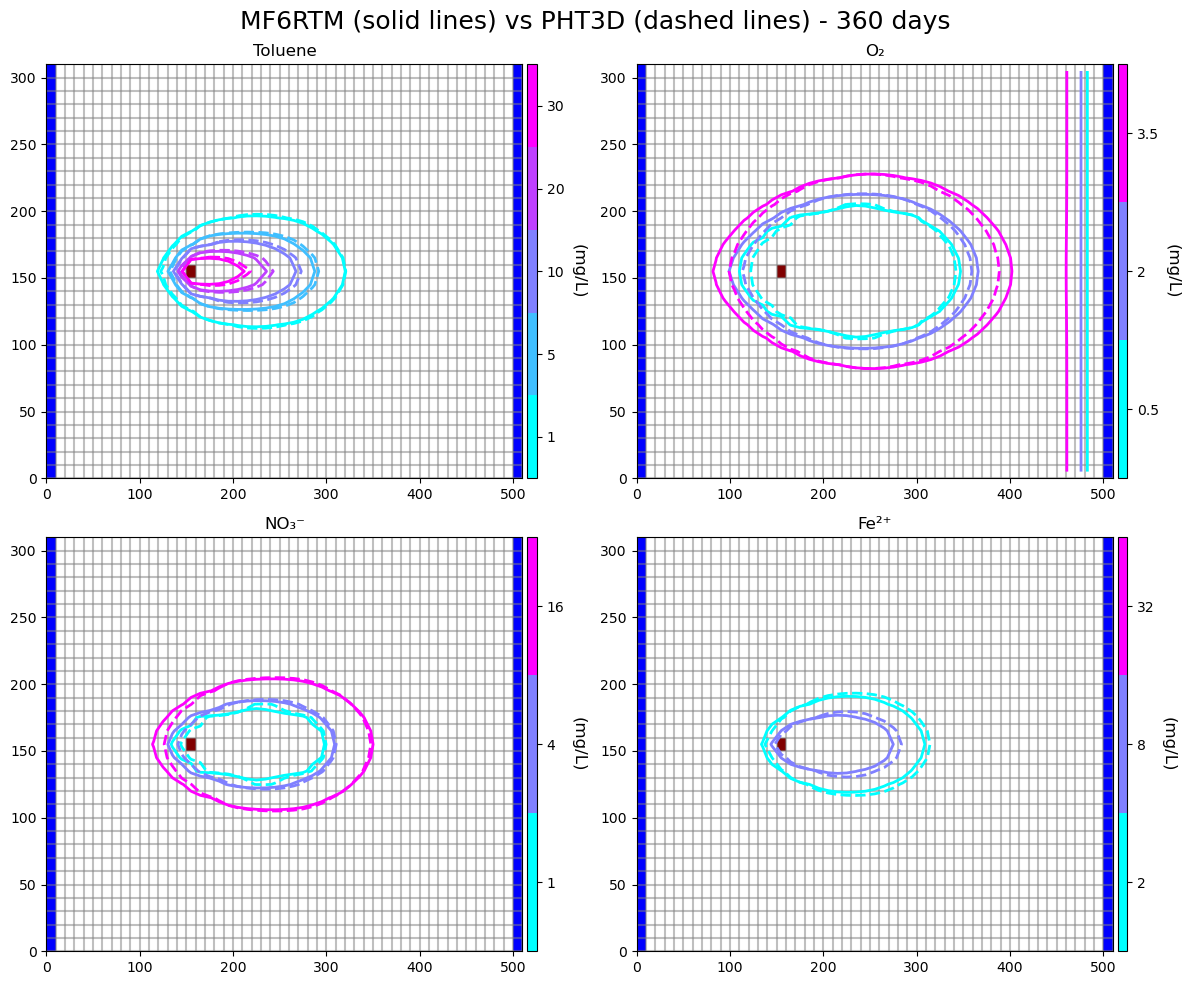

In [19]:
cm_name = 'cool'
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'MF6RTM (solid lines) vs PHT3D (dashed lines) - {int(day)} days',
             fontsize=18)
ct = 0
for c,items in comp_dict.items():

    mf6_c = find_closest_match(c, ucndict_mf6)
    pht3d_c = find_closest_match(c, ucndict_pht3d)
    print(mf6_c, pht3d_c)
    sym = items['sym'] 
    levels = items['levels']
    cmap = cm.get_cmap(cm_name, len(levels))
    rgba = [cmap(i) for i in range(len(levels))] 
    
    if c == 'N5':
        mf6_conc = mf6rtm_conc['NO3']
        # convert from mol/kgw to mg/L
        mf6_conc *= items['gfw'] * 1000 * rho 
    elif c == 'O':
        mf6_conc = mf6rtm_conc['O0']
        # convert from mol/kgw to mg/L
        mf6_conc *= items['gfw'] * 1000 * rho 
    else:
        mf6_conc = ucndict_mf6[mf6_c][mf6_tstp]
        # convert from mol/m3 to mg/L
        mf6_conc *= items['gfw']
    
    pht3d_conc = ucndict_pht3d[pht3d_c][pht3d_ts] 
    # convert from mol/kgw to mg/L
    pht3d_conc *= items['gfw'] * 1000 * rho 

    # Plot mapview
    ax = axes.flatten()[ct]
    ax.set_title(sym, fontsize=12)

    mv = flopy.plot.PlotMapView(model=gwf, layer=0, ax=ax)
    mv.plot_grid(alpha=0.5)
    cs = mv.contour_array(mf6_conc, levels=levels, colors=rgba, linewidths=2.0,
                         alpha=1., linestyles='solid')
    mv.contour_array(pht3d_conc, levels=levels, colors=rgba, linewidths=2.0,
                     alpha=1., linestyles='dashed')
    mv.plot_bc('WEL', color='maroon')
    mv.plot_bc('CHD', color='blue')
    divider = make_axes_locatable(ax)
    norm = mpl.colors.Normalize(vmin=min(cs.cvalues), vmax=max(cs.cvalues))
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cs.cmap)
    sm.set_array([])
    cax = divider.append_axes("right", size="2%", pad=0.05)
    pt = max(cs.cvalues) / len(levels) / 2 # type: ignore
    ticks = np.linspace(pt, max(cs.cvalues) - pt, len(levels)) # type: ignore
    cbar = fig.colorbar(sm, cax=cax, ticks=ticks)
    cbar.set_ticklabels(levels) # type: ignore
    cbar.set_label('(mg/L)',  rotation=270, labelpad=15, fontsize=12)
    
    ct += 1

fig.tight_layout()
plt.show()
fig.savefig(os.path.join(f'ex7_{int(day)}_days.png'), dpi=300)
plt.close()